In [ ]:
import gymnasium as gym
import numpy as np
import random


env = gym.make('FrozenLake-v1', is_slippery=True)

# Get the size of the state and action spaces
state_size = env.observation_space.n
action_size = env.action_space.n

print(f"State space size: {state_size}")
print(f"Action space size: {action_size}")


qtable = np.zeros((state_size, action_size))
print("Q-Table initialized:")
print(qtable)

# --- 3. Define Hyperparameters ---
total_episodes = 20000     # Total number of episodes to train for
learning_rate = 0.8        # (alpha) How much we update Q-values from new info
discount_factor = 0.95     # (gamma) How much we value future rewards
max_steps = 100            # Max steps per episode (prevents infinite loops)

epsilon = 1.0
max_epsilon = 1.0
min_epsilon = 0.01
decay_rate = 0.0005

# --- 4. The Q-Learning Training Loop ---
print("\n--- Starting Training ---")
rewards = []

for episode in range(total_episodes):
    # Reset the environment to a new starting state
    state = env.reset()[0]
    total_reward = 0


    for step in range(max_steps):


        tradeoff = random.uniform(0, 1)

        # 2. If random > epsilon: Exploit (choose the best action)
        if tradeoff > epsilon:
            action = np.argmax(qtable[state, :])
        # 3. Else: Explore (choose a random action)
        else:
            action = env.action_space.sample()


        new_state, reward, terminated, truncated, info = env.step(action)

        # --- Q-Table Update Rule (The Bellman Equation) ---
        # Q(s,a) = Q(s,a) + lr * [r + gamma * max(Q(s',a')) - Q(s,a)]
        qtable[state, action] = qtable[state, action] + learning_rate * \
            (reward + discount_factor * np.max(qtable[new_state, :]) - qtable[state, action])


        state = new_state
        total_reward += reward


        if terminated or truncated:
            break


    epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * episode)


    rewards.append(total_reward)


    if (episode + 1) % 2000 == 0:
        print(f"Episode {episode + 1}/{total_episodes} - Epsilon: {epsilon:.4f}")

print("--- Training Finished ---")


print("\nFinal Q-Table:")
print(qtable)

# Calculate and print average reward over the last 1000 episodes
avg_reward = sum(rewards[-1000:]) / 1000
print(f"\nAverage reward over last 1000 episodes: {avg_reward:.4f}")


# --- 6. Evaluate the Agent's Performance (No Exploration) ---
print("\n--- Evaluating Agent (Playing 10 episodes) ---")
env = gym.make('FrozenLake-v1', is_slippery=True, render_mode='human')
wins = 0
total_games = 10

for episode in range(total_games):
    state = env.reset()[0]
    print(f"\nEpisode {episode + 1}")
    env.render()

    for step in range(max_steps):
        # In evaluation, we ONLY exploit (no exploration)
        action = np.argmax(qtable[state, :])

        new_state, reward, terminated, truncated, info = env.step(action)

        state = new_state

        if terminated or truncated:
            print(f"Episode finished in {step + 1} steps.")
            if reward == 1.0:
                print("Agent reached the goal! (Win)")
                wins += 1
            else:
                print("Agent fell in a hole! (Loss)")
            break

print(f"\nEvaluation Complete: {wins}/{total_games} wins.")
env.close()

State space size: 16
Action space size: 4
Q-Table initialized:
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]

--- Starting Training ---
Episode 2000/20000 - Epsilon: 0.3744
Episode 4000/20000 - Epsilon: 0.1440
Episode 6000/20000 - Epsilon: 0.0593
Episode 8000/20000 - Epsilon: 0.0281
Episode 10000/20000 - Epsilon: 0.0167
Episode 12000/20000 - Epsilon: 0.0125
Episode 14000/20000 - Epsilon: 0.0109
Episode 16000/20000 - Epsilon: 0.0103
Episode 18000/20000 - Epsilon: 0.0101
Episode 20000/20000 - Epsilon: 0.0100
--- Training Finished ---

Final Q-Table:
[[1.33621175e-01 4.06105883e-02 7.98941480e-02 7.31347002e-02]
 [6.99416205e-03 4.29738152e-03 3.12493495e-03 1.11736474e-01]
 [8.77486683e-03 4.01355188e-03 8.02803431e-03 7.28436832e-02]
 [2.03757966e-03 1.31191786e-03 1.24989292e-02 3.34355645e-02]

#Frozen lake environment
4 x 4 agent must go from start to goal, without falling into holes
What does the state action space involve -
#What is a Q table -
16 states , 4 actions table, intialized to zero
agent's preffered course of action is to fill the table with values that tell the agent the best action to take from any state

#process
episodes - 20000, end with 1 for goal and 0 - hole
Action selection(epsilon greedy) - the exploration or exploitation is done based on the values in the q-table

update rule(bellman) - updates old q-values for previous state action, based on new estimates the might lead to better future rewards, not immediate

#what is Q- learning algorithm
learns through trial-error, consists of a q-table that the maps every possible states with every possible action and stores a Q-values for each of the pairs.
#hyper parameters involves
learning rate (low - sticks to what is already knows, high adapts to new info)
discount factor - importance to future rewards

Saved plot 1 to q_learning_reward_trend.png


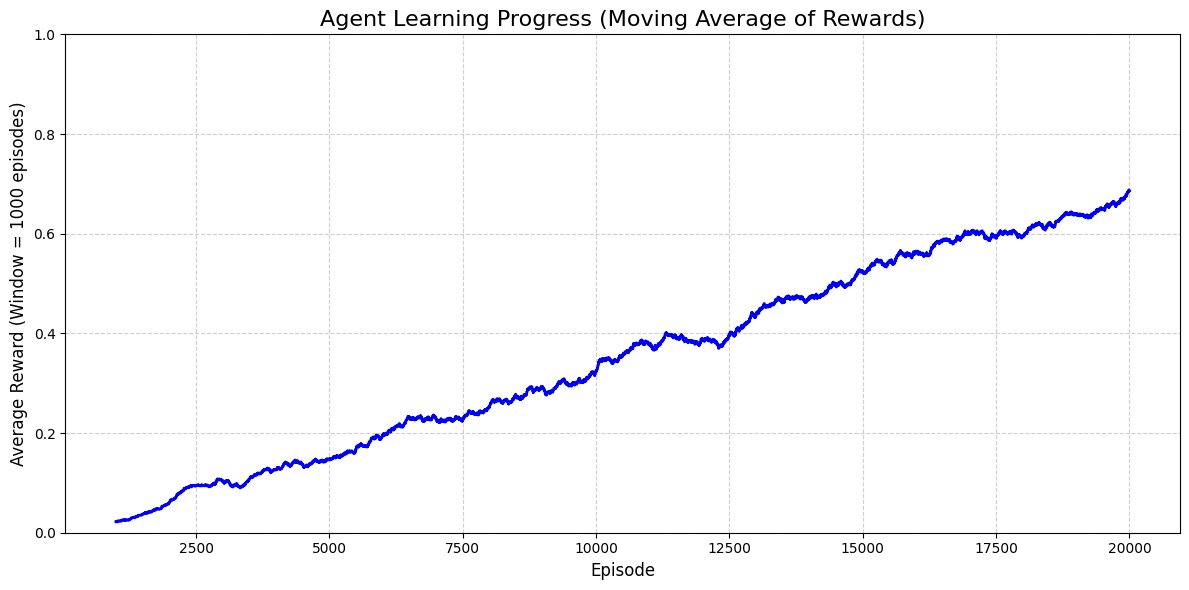

Saved plot 2 to q_learning_epsilon_decay.png


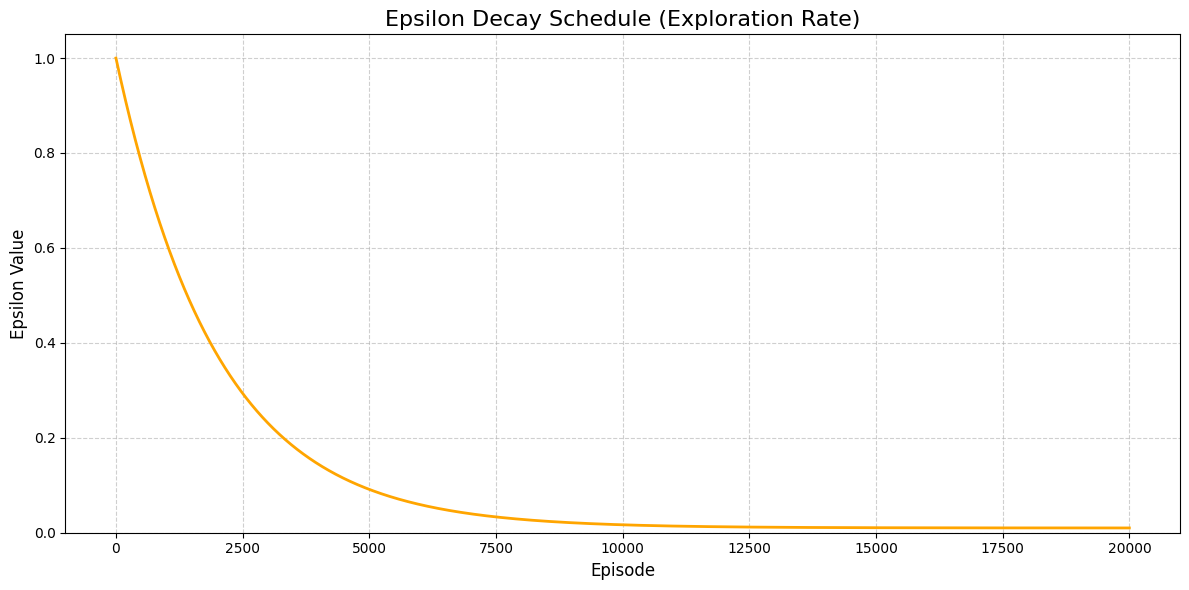

In [ ]:
import matplotlib.pyplot as plt
import numpy as np



def moving_average(data, window_size):
    """Calculates the moving average of a list."""

    if len(data) < window_size:
        return data # Not enough data to average
    return np.convolve(data, np.ones(window_size), 'valid') / window_size

# --- Mock Data Generation ---
# (Replace this with the actual data from your training loop)
total_episodes = 20000
min_epsilon = 0.01
max_epsilon = 1.0
decay_rate = 0.0005

# 1. Simulate Epsilon history
epsilon_history = [min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * ep) for ep in range(total_episodes)]


base_win_rate = np.linspace(0.01, 0.70, total_episodes)
noise = (np.random.rand(total_episodes) - 0.5) * 0.1 # Add noise
sim_rewards = (np.random.rand(total_episodes) < (base_win_rate + noise)).astype(float)
rewards = list(sim_rewards)

window_size = 1000
avg_rewards = moving_average(rewards, window_size)
avg_reward_episodes = np.arange(window_size - 1, len(rewards))

plt.figure(figsize=(12, 6))
plt.plot(avg_reward_episodes, avg_rewards, color='blue', linewidth=2)
plt.title(f'Agent Learning Progress (Moving Average of Rewards)', fontsize=16)
plt.xlabel('Episode', fontsize=12)
plt.ylabel(f'Average Reward (Window = {window_size} episodes)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0, 1) # Set Y-axis from 0 (min reward) to 1 (max reward)
plt.tight_layout()
plt.savefig('q_learning_reward_trend.png')
print("Saved plot 1 to q_learning_reward_trend.png")
plt.show()


# --- 2. Plot 2: Epsilon Decay (Exploration vs. Exploitation) ---

plt.figure(figsize=(12, 6))
plt.plot(epsilon_history, color='orange', linewidth=2)
plt.title('Epsilon Decay Schedule (Exploration Rate)', fontsize=16)
plt.xlabel('Episode', fontsize=12)
plt.ylabel('Epsilon Value', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0, 1.05) # Set Y-axis from 0 to 1.05
plt.tight_layout()
plt.savefig('q_learning_epsilon_decay.png')
print("Saved plot 2 to q_learning_epsilon_decay.png")
plt.show()